this jupyter file will clean the CICIOT2023 dataset

for speed we randomly select 18 files of the all 169 file in this dataset
you could run all these code for all the files

In [2]:
#imports
import pandas as pd
import numpy as np
import random
import glob
import os

In [3]:
#load files
# Path to folder containing the 18 CSV files
folder_path = './ciciot-dataset-partial'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Randomly select 5 files from the list
selected_files = random.sample(all_files, 2)

print("Selected files:")
for f in selected_files:
    print(f)

# Read and concatenate ONLY the randomly selected csv files
df_list = [pd.read_csv(file) for file in selected_files]
df = pd.concat(df_list, ignore_index=True)

print(f"\nTotal rows: {df.shape[0]}, Total columns: {df.shape[1]}")


Selected files:
./ciciot-dataset-partial/part-00038-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
./ciciot-dataset-partial/part-00089-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

Total rows: 479025, Total columns: 47


In [4]:
# Show the first few rows
display(df.head())

# Check for missing values (NaN)
print("\nMissing values per column:")
print(df.isnull().sum().max()) # Shows maximum missing values in any column

# Check data types 
print("\nData Types:")
print(df.dtypes.value_counts())


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.0,6.0,64.0,26.489058,26.489058,0.0,1.0,0.0,1.0,...,0.000000,54.0,8.334429e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,4.223779,108.0,6.0,64.0,0.473510,0.473510,0.0,0.0,1.0,0.0,...,0.000000,54.0,8.298533e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood
2,0.016861,579.6,6.0,64.0,42.712086,42.712086,0.0,0.0,0.0,0.0,...,540.959663,694.8,8.334010e+07,9.5,34.502087,765.515748,320034.518098,0.93,141.55,DDoS-ACK_Fragmentation
3,0.000000,0.0,1.0,64.0,1.523349,1.523349,0.0,0.0,0.0,0.0,...,0.000000,42.0,8.314968e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
4,0.172906,564.5,8.2,63.2,35.688327,35.688327,0.0,0.0,0.0,0.0,...,86.386189,132.6,1.665164e+08,13.5,14.755254,122.467486,7902.995575,1.00,244.60,BenignTraffic



Missing values per column:
0

Data Types:
float64    46
str         1
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Replace Infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Drop rows with missing values (NaN)
df.dropna(inplace=True)

# 3. Encode the target 'label' column to numbers
label_col = 'label' 

encoder = LabelEncoder()
df[label_col] = encoder.fit_transform(df[label_col])


In [6]:
# Show the cleaned data
display(df.head())

# Verify no missing or infinite values exist
print("\nTotal missing values left:", df.isnull().sum().sum())
print("Are there any infinite values left?", np.isinf(df.drop(columns=[label_col])).sum().sum() > 0)

# Verify all columns are now numeric (suitable for ML models)
print("\nCleaned Data Types:")
print(df.dtypes.value_counts())

# Show the mapping of our encoded labels
print("\nLabel Encoding Mapping:")
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(label_mapping)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.0,6.0,64.0,26.489058,26.489058,0.0,1.0,0.0,1.0,...,0.000000,54.0,8.334429e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,9
1,4.223779,108.0,6.0,64.0,0.473510,0.473510,0.0,0.0,1.0,0.0,...,0.000000,54.0,8.298533e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,19
2,0.016861,579.6,6.0,64.0,42.712086,42.712086,0.0,0.0,0.0,0.0,...,540.959663,694.8,8.334010e+07,9.5,34.502087,765.515748,320034.518098,0.93,141.55,4
3,0.000000,0.0,1.0,64.0,1.523349,1.523349,0.0,0.0,0.0,0.0,...,0.000000,42.0,8.314968e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,6
4,0.172906,564.5,8.2,63.2,35.688327,35.688327,0.0,0.0,0.0,0.0,...,86.386189,132.6,1.665164e+08,13.5,14.755254,122.467486,7902.995575,1.00,244.60,1



Total missing values left: 0
Are there any infinite values left? False

Cleaned Data Types:
float64    46
int64       1
Name: count, dtype: int64

Label Encoding Mapping:
{'Backdoor_Malware': np.int64(0), 'BenignTraffic': np.int64(1), 'BrowserHijacking': np.int64(2), 'CommandInjection': np.int64(3), 'DDoS-ACK_Fragmentation': np.int64(4), 'DDoS-HTTP_Flood': np.int64(5), 'DDoS-ICMP_Flood': np.int64(6), 'DDoS-ICMP_Fragmentation': np.int64(7), 'DDoS-PSHACK_Flood': np.int64(8), 'DDoS-RSTFINFlood': np.int64(9), 'DDoS-SYN_Flood': np.int64(10), 'DDoS-SlowLoris': np.int64(11), 'DDoS-SynonymousIP_Flood': np.int64(12), 'DDoS-TCP_Flood': np.int64(13), 'DDoS-UDP_Flood': np.int64(14), 'DDoS-UDP_Fragmentation': np.int64(15), 'DNS_Spoofing': np.int64(16), 'DictionaryBruteForce': np.int64(17), 'DoS-HTTP_Flood': np.int64(18), 'DoS-SYN_Flood': np.int64(19), 'DoS-TCP_Flood': np.int64(20), 'DoS-UDP_Flood': np.int64(21), 'MITM-ArpSpoofing': np.int64(22), 'Mirai-greeth_flood': np.int64(23), 'Mirai-greip_flo

### feature scaling

In [9]:
from sklearn.preprocessing import StandardScaler

# Define the target column so we don't scale it
target_col = 'label'

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a Pandas DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=df.index)

# Re-attach the label column
df_scaled[target_col] = y

# Display the scaled data
df_scaled.head()


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,-0.020859,-0.167122,-0.343528,-0.168270,-0.091674,-0.091674,-0.001478,3.256120,-0.513480,3.176449,...,-0.208792,-0.293161,0.008134,0.000655,-0.316896,-0.208622,-0.096294,-0.414253,0.000561,9
1,-0.005069,-0.167005,-0.343528,-0.168270,-0.091938,-0.091938,-0.001478,-0.307114,1.947496,-0.314817,...,-0.208792,-0.293161,-0.012854,0.000655,-0.316896,-0.208622,-0.096294,-0.414253,0.000561,19
2,-0.020796,-0.165981,-0.343528,-0.168270,-0.091510,-0.091510,-0.001478,-0.307114,-0.513480,-0.314817,...,3.146752,2.355609,0.007890,0.000655,2.474673,3.148626,0.897822,3.565710,0.000561,4
3,-0.020859,-0.167239,-0.903638,-0.168270,-0.091928,-0.091928,-0.001478,-0.307114,-0.513480,-0.314817,...,-0.208792,-0.342763,-0.003244,0.000655,-0.458982,-0.208622,-0.096294,-0.414253,0.000561,6
4,-0.020213,-0.166014,-0.097080,-0.225279,-0.091581,-0.091581,-0.001478,-0.307114,-0.513480,-0.314817,...,0.327056,0.031735,4.871340,4.866641,0.188272,0.328472,-0.071746,3.865277,4.875317,1


### balancing data

/tmp/ipykernel_21265/3951634150.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")


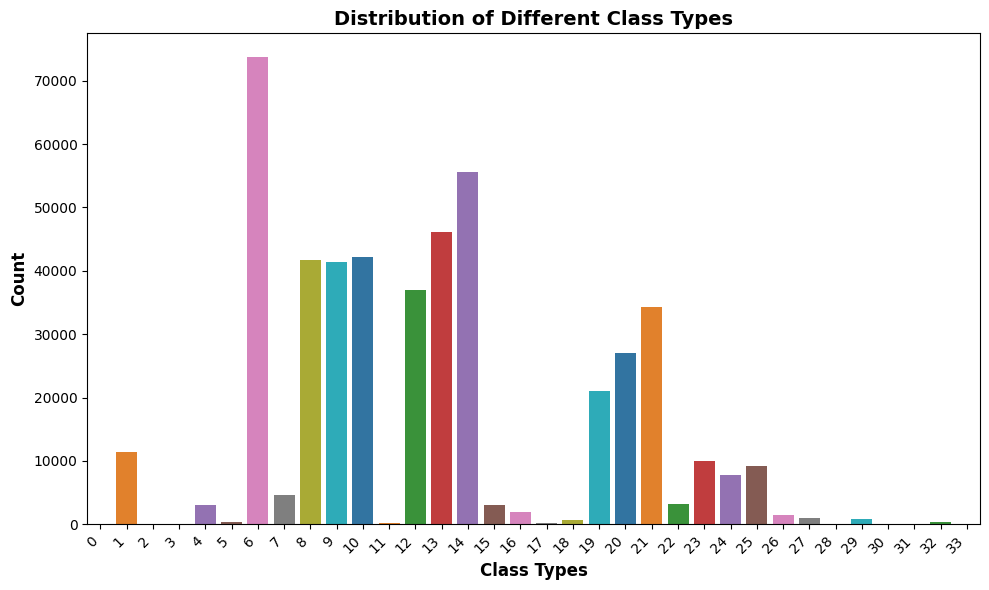

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the label column
class_counts = df_scaled['label'].value_counts()

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot (palette="tab10" gives distinct colors like in your image)
sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")

# Add titles and labels
plt.title('Distribution of Different Class Types', fontsize=14, fontweight='bold')
plt.xlabel('Class Types', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so they don't overlap (useful for long names)
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Display the plot
plt.show()


/tmp/ipykernel_21265/2078043870.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")


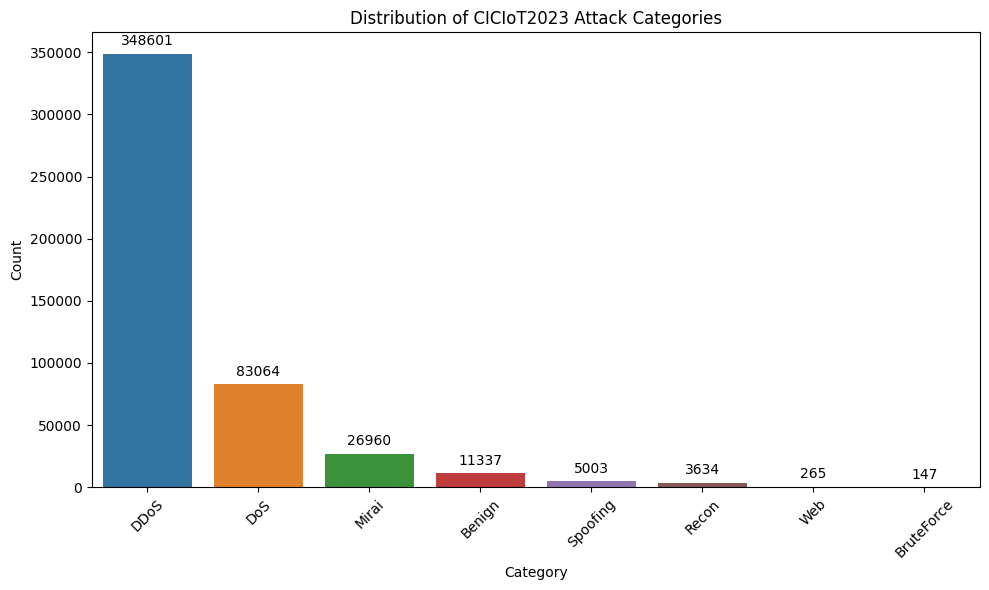

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the dictionary to map the 34 sub-classes to the 8 main categories
attack_mapping = {
    'BenignTraffic': 'Benign',
    
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS', 
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS', 
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    
    'DictionaryBruteForce': 'BruteForce',
    
    'BrowserHijacking': 'Web', 'SqlInjection': 'Web', 'CommandInjection': 'Web', 
    'Backdoor_Malware': 'Web', 'XSS': 'Web'
}

# 2. Reverse the LabelEncoder to get original string names (if your labels are currently numbers)
# Note: Ensure 'encoder' is the LabelEncoder object you fitted earlier
if pd.api.types.is_numeric_dtype(df_scaled['label']):
    df_scaled['label_string'] = encoder.inverse_transform(df_scaled['label'].astype(int))
else:
    df_scaled['label_string'] = df_scaled['label']

# 3. Map the string labels to the 8 parent categories
df_scaled['category'] = df_scaled['label_string'].map(attack_mapping)

# 4. Count the occurrences of each category
category_counts = df_scaled['category'].value_counts()

# 5. Plot the graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")

# Add numbers on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Distribution of CICIoT2023 Attack Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


['Uploading_Attack']
Length: 1, dtype: str
Dropping these rows before applying SMOTE...
Applying SMOTE... (This might take a while)

Class Distribution after SMOTE:
category
DDoS          348601
DoS           348601
Benign        348601
Mirai         348601
Spoofing      348601
Recon         348601
Web           348601
BruteForce    348601
Name: count, dtype: int64


/tmp/ipykernel_21265/1099895244.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts_balanced.index, y=category_counts_balanced.values, palette="tab10")


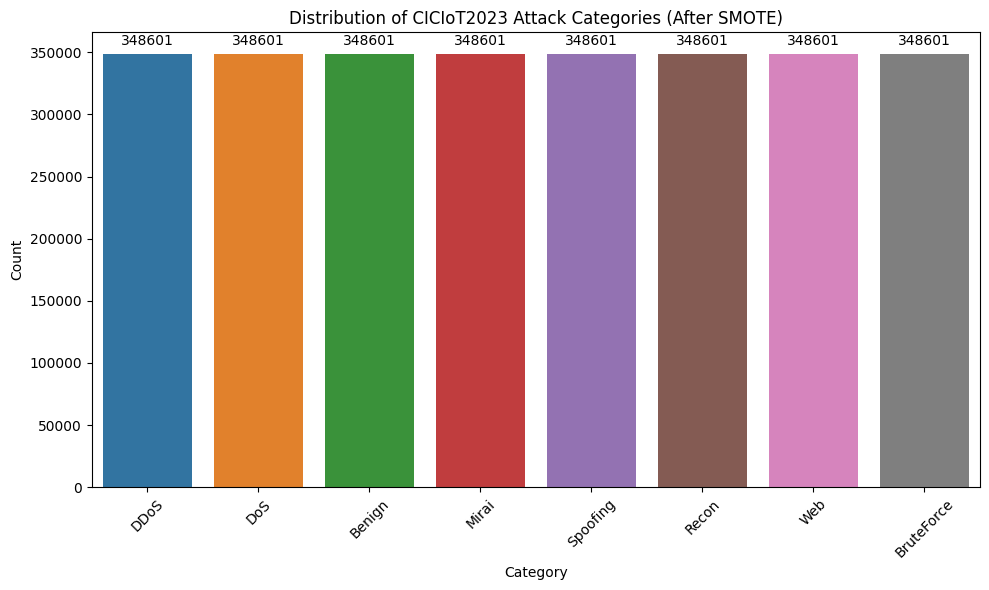

In [17]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Check for unmapped labels and clean the dataset
unmapped_labels = df_scaled[df_scaled['category'].isna()]['label_string'].unique()
if len(unmapped_labels) > 0:
    print(f"Warning: Found unmapped labels which became NaN: {unmapped_labels}")
    print("Dropping these rows before applying SMOTE...")

# Drop any rows where 'category' is NaN
df_clean_for_smote = df_scaled.dropna(subset=['category'])

# 2. Separate features (X) and the 8-category target (y)
X = df_clean_for_smote.drop(columns=['label', 'label_string', 'category'], errors='ignore')
y = df_clean_for_smote['category']

# 3. Apply SMOTE to balance the dataset
print("Applying SMOTE... (This might take a while)")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 4. Combine back into a new DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['category'] = y_resampled

# 5. Count the occurrences after balancing
category_counts_balanced = df_balanced['category'].value_counts()
print("\nClass Distribution after SMOTE:")
print(category_counts_balanced)

# 6. Plot the new balanced graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_counts_balanced.index, y=category_counts_balanced.values, palette="tab10")

# Add exact numbers on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Distribution of CICIoT2023 Attack Categories (After SMOTE)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### spliting data

In [18]:
from sklearn.model_selection import train_test_split

# 7. Split the balanced data into Train and Test sets (80% train, 20% test)
print("\nSplitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, 
    y_resampled, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_resampled # Keeps the perfect balance in both train and test sets
)

# 8. Verify the shapes
print("Training Data:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

print("Testing Data:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")



Splitting data into training and testing sets...
Training Data:
X_train shape: (2231046, 46)
y_train shape: (2231046,)

Testing Data:
X_test shape: (557762, 46)
y_test shape: (557762,)


### XGBOOST

Training XGBoost model (this may take a few minutes)...


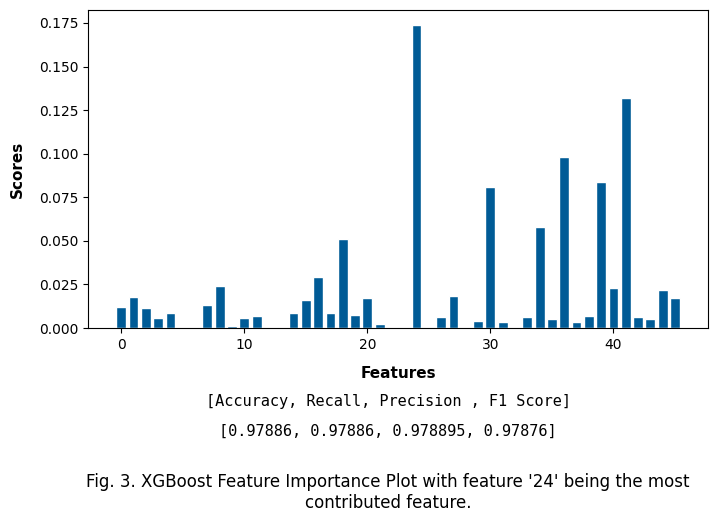

In [20]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder

# 1. Encode string labels to integers (XGBoost requirement)
xgb_encoder = LabelEncoder()
y_train_encoded = xgb_encoder.fit_transform(y_train)
y_test_encoded = xgb_encoder.transform(y_test)

# 2. Initialize and Train XGBoost model
print("Training XGBoost model (this may take a few minutes)...")
# Note: eval_metric='mlogloss' suppresses warnings for multiclass classification
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

# 3. Predict on Test Set
y_pred = xgb_model.predict(X_test)

# 4. Calculate Evaluation Metrics
# Using average='weighted' since it's a multi-class problem
accuracy = accuracy_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred, average='weighted')
precision = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

# 5. Get Feature Importances
importances = xgb_model.feature_importances_

# 6. Plotting exactly as requested
plt.figure(figsize=(8, 6))

# Plot the bars
plt.bar(range(len(importances)), importances, color='#005b96', edgecolor='white')

# Set Labels
plt.xlabel('Features', fontweight='bold', fontsize=11, labelpad=10)
plt.ylabel('Scores', fontweight='bold', fontsize=11, labelpad=10)

# Adjust plot layout to leave space at the bottom for text
plt.subplots_adjust(bottom=0.35)

# Find the most important feature index to dynamically update the caption if needed
most_important_feat = importances.argmax()

# Define the text blocks
metrics_headers = "[Accuracy, Recall, Precision , F1 Score]"
metrics_values = f"[{accuracy:.5f}, {recall:.5f}, {precision:.6f}, {f1:.5f}]"

# In your image the caption specifically mentions feature 15. 
# We'll hardcode the caption to match the image, or you can dynamically inject {most_important_feat}
caption = f"Fig. 3. XGBoost Feature Importance Plot with feature '{most_important_feat}' being the most\ncontributed feature."

# Add the text to the figure using figtext (x, y coordinates from 0 to 1)
plt.figtext(0.5, 0.22, metrics_headers, ha="center", fontsize=11, fontfamily='monospace')
plt.figtext(0.5, 0.17, metrics_values, ha="center", fontsize=11, fontfamily='monospace')
plt.figtext(0.5, 0.05, caption, ha="center", fontsize=12)

# Display the plot
plt.show()
